In [ ]:
from google.colab import files
import pandas as pd
import re
import json
from google import genai
from google.colab import userdata

In [ ]:
import sqlite3
import random
from datetime import datetime, timedelta

db_path = "/tmp/samsung_factory.db"

conn = sqlite3.connect(db_path)
cursor = conn.cursor()

# -----------------------------
# Create Tables
# -----------------------------

cursor.execute("""
CREATE TABLE IF NOT EXISTS inventory (
    item_id INTEGER PRIMARY KEY,
    name TEXT,
    sku TEXT,
    stock_level INTEGER,
    reorder_point INTEGER
)
""")

cursor.execute("""
CREATE TABLE IF NOT EXISTS production_line (
    entry_id INTEGER PRIMARY KEY,
    model_id TEXT,
    shift TEXT,
    units_produced INTEGER,
    timestamp TEXT
)
""")

cursor.execute("""
CREATE TABLE IF NOT EXISTS shipping (
    order_id INTEGER PRIMARY KEY,
    destination TEXT,
    quantity INTEGER,
    status TEXT
)
""")

# -----------------------------
# Insert Inventory (50 rows)
# -----------------------------

items = [
    "32-inch LED Panel",
    "43-inch LED Panel",
    "50-inch UHD Panel",
    "55-inch Crystal UHD Panel",
    "65-inch QLED Panel",
    "75-inch QLED Panel",
    "85-inch UHD Panel",
    "OLED Control Board",
    "Power Supply Unit",
    "TV Mainboard"
]

for i in range(1, 51):
    name = random.choice(items)
    sku = f"SKU-{1000+i}"
    stock = random.randint(50, 500)
    reorder = random.randint(80, 200)

    cursor.execute(
        "INSERT INTO inventory VALUES (?, ?, ?, ?, ?)",
        (i, name, sku, stock, reorder)
    )

# -----------------------------
# Insert Production Data (900 rows)
# -----------------------------

models = ["TV-32", "TV-43", "TV-55", "TV-65", "TV-75", "TV-85"]
shifts = ["A", "B"]

base_time = datetime.now()

for i in range(1, 901):
    model = random.choice(models)
    shift = random.choice(shifts)
    units = random.randint(5, 20)
    time = base_time - timedelta(minutes=random.randint(0, 1440))

    cursor.execute(
        "INSERT INTO production_line VALUES (?, ?, ?, ?, ?)",
        (i, model, shift, units, time.strftime("%Y-%m-%d %H:%M:%S"))
    )

# -----------------------------
# Insert Shipping (50 rows)
# -----------------------------

destinations = [
    "Kathmandu Distribution Center",
    "Pokhara Warehouse",
    "Birgunj Retail Hub",
    "Butwal Logistics",
    "Dharan Electronics Market"
]

statuses = ["Pending", "Shipped", "Delivered"]

for i in range(1, 51):
    dest = random.choice(destinations)
    qty = random.randint(10, 120)
    status = random.choice(statuses)

    cursor.execute(
        "INSERT INTO shipping VALUES (?, ?, ?, ?)",
        (i, dest, qty, status)
    )

conn.commit()
conn.close()

print("Database created with 1000 records")

Database created with 1000 records


In [ ]:
schema_prompt = """
You are a SQL generator for a manufacturing database.

Database schema:

Table: inventory
- item_id
- name
- sku
- stock_level
- reorder_point

Table: production_line
- entry_id
- model_id
- shift
- units_produced
- timestamp

Table: shipping
- order_id
- destination
- quantity
- status

Rules:
- Only generate SELECT queries
- Never generate DELETE, UPDATE, DROP
- Return SQL only
"""

In [ ]:
#Gemini configuration
import google.generativeai as genai

genai.configure(api_key=userdata.get("GOOGLE_API_KEY"))
model = genai.GenerativeModel("gemini-2.5-flash")

In [ ]:
def generate_sql(question):

    prompt = schema_prompt + "\nUser Question:\n" + question

    # The 'model' variable is expected to be an instance of google.generativeai.GenerativeModel
    # Ensure that 'genai' is imported correctly as 'import google.generativeai as genai'
    # and that 'model' is initialized from it (e.g., model = genai.GenerativeModel('gemini-2.5-flash'))
    response = model.generate_content(prompt)

    sql_query = response.text.strip().replace("```sql","").replace("```","")

    return sql_query

In [ ]:
def validate_query(sql):

    forbidden = ["DELETE", "UPDATE", "DROP", "INSERT", "ALTER"]

    for word in forbidden:
        if word in sql.upper():
            raise ValueError("Unsafe SQL detected")

    return True

In [ ]:
import pandas as pd

def run_query(sql):

    conn = sqlite3.connect(db_path)

    df = pd.read_sql_query(sql, conn)

    conn.close()

    return df

In [ ]:
question = "Show current stock of 85-inch UHD Panel compared to reorder level"

sql = generate_sql(question)

print("Generated SQL:")
print(sql)

validate_query(sql)

df = run_query(sql)

df

Generated SQL:

SELECT
  name,
  stock_level,
  reorder_point
FROM inventory
WHERE
  name = '85-inch UHD Panel';



,name,stock_level,reorder_point
0,85-inch UHD Panel,105,134
1,85-inch UHD Panel,406,80
2,85-inch UHD Panel,309,122
3,85-inch UHD Panel,265,95


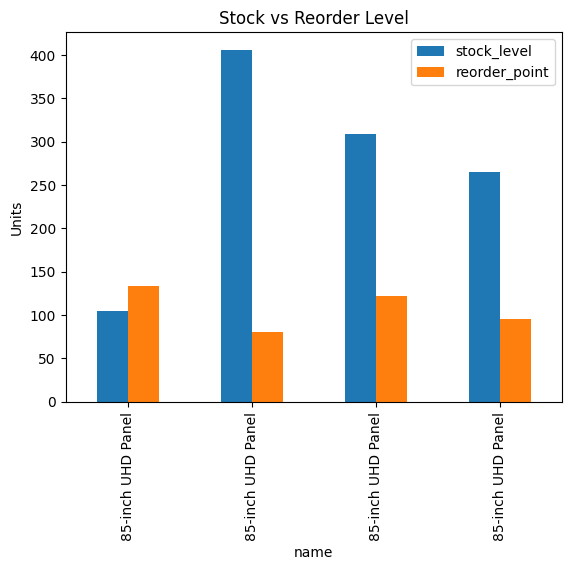

In [ ]:
import matplotlib.pyplot as plt

df.set_index("name")[["stock_level","reorder_point"]].plot(kind="bar")

plt.title("Stock vs Reorder Level")
plt.ylabel("Units")
plt.show()

In [ ]:
question = "Show stock of 85-inch UHD panels vs reorder level"

sql = generate_sql(question)

print("Generated SQL:")
print(sql)

validate_query(sql)

df = run_query(sql)

df

Generated SQL:

SELECT name, stock_level, reorder_point
FROM inventory
WHERE name LIKE '%85-inch UHD panels%';



,name,stock_level,reorder_point


In [ ]:
question = "Show Total TVs produced by model"

sql = generate_sql(question)

print("Generated SQL:")
print(sql)

validate_query(sql)

df = run_query(sql)

df

Generated SQL:

SELECT
  model_id,
  SUM(units_produced) AS total_tvs_produced
FROM production_line
GROUP BY
  model_id;



,model_id,total_tvs_produced
0,TV-32,2029
1,TV-43,1881
2,TV-55,1607
3,TV-65,1759
4,TV-75,2272
5,TV-85,1742


In [ ]:
question = "How many units were produced in shift A today"

sql = generate_sql(question)

print("Generated SQL:")
print(sql)

validate_query(sql)

df = run_query(sql)

df

Generated SQL:

SELECT SUM(units_produced)
FROM production_line
WHERE shift = 'A' AND DATE(timestamp) = CURRENT_DATE;



,SUM(units_produced)
0,5099


In [ ]:
question = "Show all pending shipments"

sql = generate_sql(question)

print("Generated SQL:")
print(sql)

validate_query(sql)

df = run_query(sql)

df

Generated SQL:

SELECT *
FROM shipping
WHERE status = 'pending';



,order_id,destination,quantity,status
